In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Load audio

In [2]:
import scipy.io.wavfile as wav

samplerate , data  = wav.read("Recording.wav")

In [3]:
mono_data = data.mean(axis=1)

In [4]:
max_audio = np.max(np.abs(mono_data))
max_audio

np.float64(1862.0)

In [5]:
audio = mono_data / max_audio

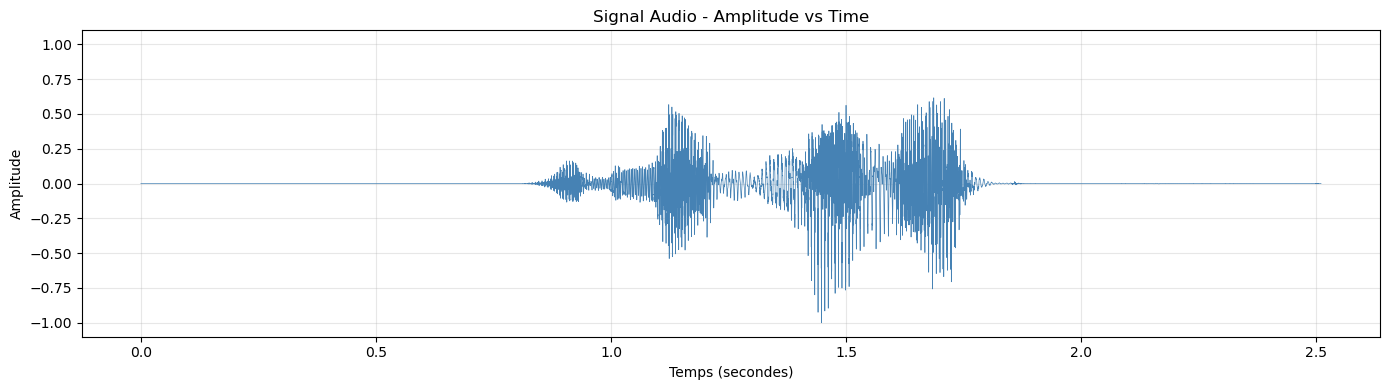

In [6]:
sr = 48000

time = np.linspace(0 , len(audio) / sr , len(audio))

plt.figure(figsize=(14, 4))
plt.plot(time, audio, color='steelblue', linewidth=0.5)
plt.title("Signal Audio - Amplitude vs Time")
plt.xlabel("Temps (secondes)")
plt.ylabel("Amplitude")
plt.ylim(-1.1, 1.1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
print(samplerate)

48000


In [8]:
f_max = samplerate/2

In [9]:
n_fft = 1024
hop_length = 512

In [10]:
N = n_fft
n = np.arange(N)

hann_window = 0.5 * (1 - np.cos((2 * np.pi * n) / (N - 1)))

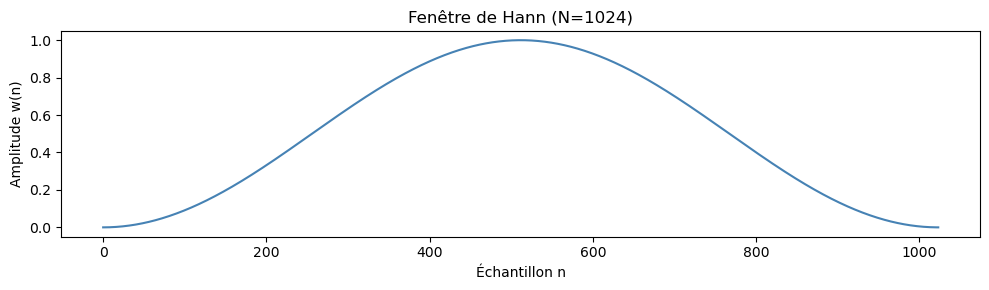

In [11]:
plt.figure(figsize=(10, 3))
plt.plot(hann_window, color='steelblue')
plt.title(f'Fenêtre de Hann (N={len(hann_window)})')
plt.xlabel('Échantillon n')
plt.ylabel('Amplitude w(n)')
plt.tight_layout()
plt.show()


In [12]:
frames_number = (len(audio) - n_fft) // hop_length + 1
print(frames_number)

234


In [13]:
remainder = (len(audio) - n_fft) % hop_length
pad_length = (hop_length - remainder) % hop_length

audio_padded = np.pad(audio, (0, pad_length))

In [14]:
frame = np.zeros((frames_number, n_fft))
for i in range(frames_number):
    start = i * hop_length
    end = start + n_fft
    frame[i] = audio[start:end] * hann_window

In [15]:
frame.shape

(234, 1024)

In [16]:
spectrum = np.fft.rfft(frame, n=n_fft)

In [17]:
spectrum.shape

(234, 513)

In [18]:
magnitude = np.abs(spectrum)

In [19]:
magnitude

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.01092226, 0.06056623, 0.10441736, ..., 0.00059671, 0.00072332,
        0.00036856],
       [0.0314105 , 0.0318335 , 0.07956638, ..., 0.00092911, 0.00067559,
        0.00023481],
       [0.00966073, 0.02446866, 0.07801408, ..., 0.00138651, 0.00014748,
        0.00029745]])

In [20]:
spectrogram = magnitude.T

In [21]:
log_spec = 20 * np.log10(magnitude + 1e-10)

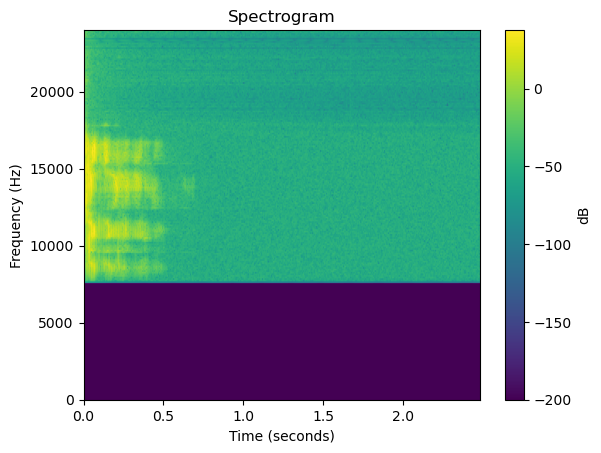

In [24]:
freqs = np.fft.rfftfreq(n_fft, d=1/sr)
times = np.arange(frames_number) * hop_length / sr

plt.imshow(
    log_spec,
    aspect='auto',
    origin='lower',
    extent=[times[0], times[-1], freqs[0], freqs[-1]]
)

plt.colorbar(label="dB")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram")
plt.show()